In [1]:
# ============ HÜCRE 1 — Kurulum + Tohum + Otomatik Klasörler ============
import sys
sys.path.append('F:/CancerDataClassification/src')

import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib, random, json

import dataset
importlib.reload(dataset)
from dataset import HAMDataset, get_transforms, get_weighted_sampler

from models import pretrained_models
importlib.reload(pretrained_models)
from models.pretrained_models import get_model, count_parameters

import train as train_module
importlib.reload(train_module)
from train import train_model

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42   # <-- HER KOŞUDA SADECE BURAYI DEĞİŞTİR: 13, sonra 21, sonra 42
set_seed(SEED)

BASE = Path('F:/CancerDataClassification')
DATA = BASE / 'data'
MODELS_DIR = BASE / 'models/multiclass'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Bu tohumun kendi klasörü (grafik + tablo otomatik buraya)
SEED_DIR = BASE / f'results/multiclass/seed{SEED}'
FIG = SEED_DIR / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

def mpath(name):  # tohum-etiketli model dosyası
    return str(MODELS_DIR / f'{name}_multiclass_seed{SEED}.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# Bu tohumun tablo sonuçlarını biriktireceğimiz sözlükler
val_results_multi = {}
test_results_multi = {}

print(f"Tohum: {SEED} | Device: {device}")
print(f"Sonuçlar buraya: {SEED_DIR}")

C:\Users\Lada\.conda\envs\cancer_cls\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [WinError 10054] Удаленный хост принудительно разорвал существующее подключение>
  data = fetch_version_info()


Tohum: 42 | Device: cuda
Sonuçlar buraya: F:\CancerDataClassification\results\multiclass\seed42


In [2]:
# ============ HÜCRE 2 — DataLoader (300px, batch 16, WeightedSampler) ============
IMAGE_SIZE = 300
BATCH_SIZE = 16

train_dataset = HAMDataset(
    csv_path=str(DATA / 'multiclass_train_balanced.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='train', use_augmentation=True))
val_dataset = HAMDataset(
    csv_path=str(DATA / 'split_val.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='val'))

sampler = get_weighted_sampler(train_dataset, target_per_class=500)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0, pin_memory=True)

print(f"Image size: {IMAGE_SIZE} | Batch: {BATCH_SIZE} | Train batches: {len(train_loader)}")

WeightedRandomSampler hazır:
  Sınıf sayıları: [222, 361, 500, 71, 500, 500, 99]
  Hedef per class: 500
  Toplam sample/epoch: 3500
Image size: 300 | Batch: 16 | Train batches: 219


# EfficientNet-B3 model

In [3]:
# ============ HÜCRE 3 — EfficientNet-B3 Eğitim ============
set_seed(SEED)
model = get_model('efficientnet_b3', num_classes=7, pretrained=True)
print(f"EfficientNet-B3 | Parametreler: {count_parameters(model):,}")

history_b3_multi = train_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    epochs=30, max_lr=0.0008, save_path=mpath('efficientnet_b3'),
    device=device, pct_start=0.3)

EfficientNet-B3 | Parametreler: 10,706,991
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\multiclass\efficientnet_b3_multiclass_seed42.pth


Epoch   1/30 | Train Loss: 1.9369 Acc: 16.09% | Val Loss: 1.9264 Acc: 18.02% | LR: 0.00006 | Time: 77.7s
   💾 Best model saved! Val Acc: 18.02%


Epoch   2/30 | Train Loss: 1.8917 Acc: 23.31% | Val Loss: 1.8370 Acc: 33.36% | LR: 0.00012 | Time: 76.1s
   💾 Best model saved! Val Acc: 33.36%


Epoch   3/30 | Train Loss: 1.8055 Acc: 36.54% | Val Loss: 1.6681 Acc: 50.85% | LR: 0.00022 | Time: 75.7s
   💾 Best model saved! Val Acc: 50.85%


Epoch   4/30 | Train Loss: 1.6694 Acc: 44.63% | Val Loss: 1.4462 Acc: 58.55% | LR: 0.00035 | Time: 76.1s
   💾 Best model saved! Val Acc: 58.55%


...

Epoch  26/30 | Train Loss: 0.5539 Acc: 80.03% | Val Loss: 0.5952 Acc: 76.24% | LR: 0.00007 | Time: 76.6s


Epoch  27/30 | Train Loss: 0.5569 Acc: 79.49% | Val Loss: 0.6501 Acc: 74.35% | LR: 0.00004 | Time: 76.1s


Epoch  28/30 | Train Loss: 0.5707 Acc: 79.31% | Val Loss: 0.6321 Acc: 74.28% | LR: 0.00002 | Time: 76.1s


Epoch  29/30 | Train Loss: 0.5681 Acc: 79.11% | Val Loss: 0.6018 Acc: 75.13% | LR: 0.00000 | Time: 76.0s


Epoch  30/30 | Train Loss: 0.5318 Acc: 80.94% | Val Loss: 0.6262 Acc: 74.80% | LR: 0.00000 | Time: 75.7s

EĞİTİM BİTTİ - Toplam süre: 39.1 dakika
En iyi Val Acc: 78.46%
Model kaydedildi: F:\CancerDataClassification\models\multiclass\efficientnet_b3_multiclass_seed42.pth


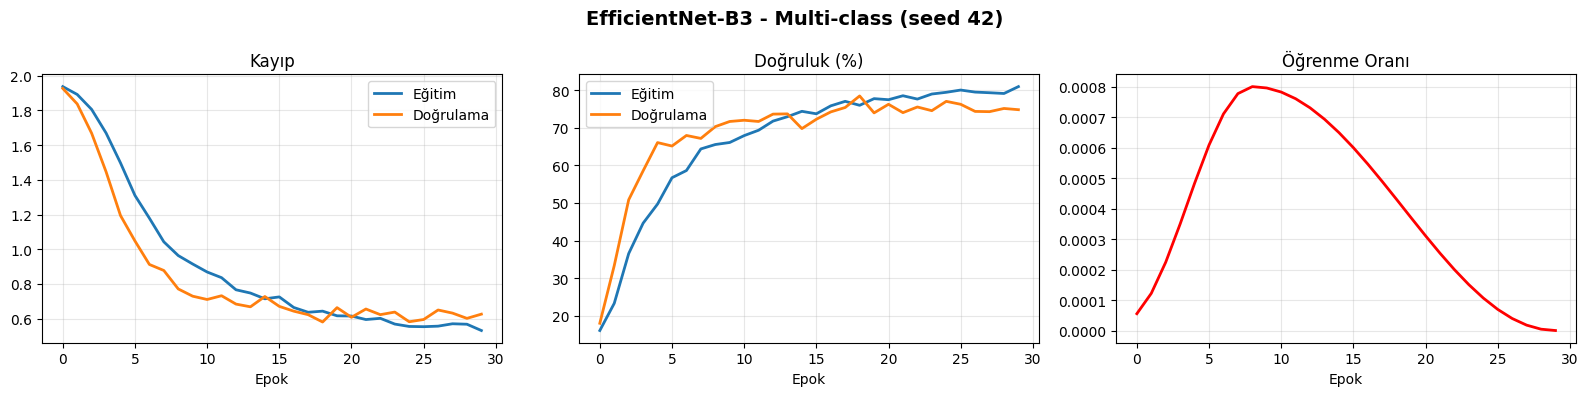

In [4]:
# ============ HÜCRE 4 — EfficientNet-B3 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_b3_multi['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_b3_multi['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_b3_multi['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_b3_multi['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_b3_multi['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'EfficientNet-B3 - Multi-class (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG / 'efficientnet_b3_training.png', dpi=150)
plt.show()

EfficientNet-B3 (val): {'acc': 78.45953002610966, 'macro_f1': 67.5458472700888, 'weighted_f1': 79.6919632153166}
              precision    recall  f1-score   support

       akiec      0.579     0.623     0.600        53
         bcc      0.690     0.841     0.758        82
         bkl      0.598     0.669     0.631       160
          df      0.452     0.792     0.576        24
         mel      0.496     0.728     0.590       173
          nv      0.952     0.816     0.879      1018
        vasc      0.630     0.773     0.694        22

    accuracy                          0.785      1532
   macro avg      0.628     0.749     0.675      1532
weighted avg      0.824     0.785     0.797      1532



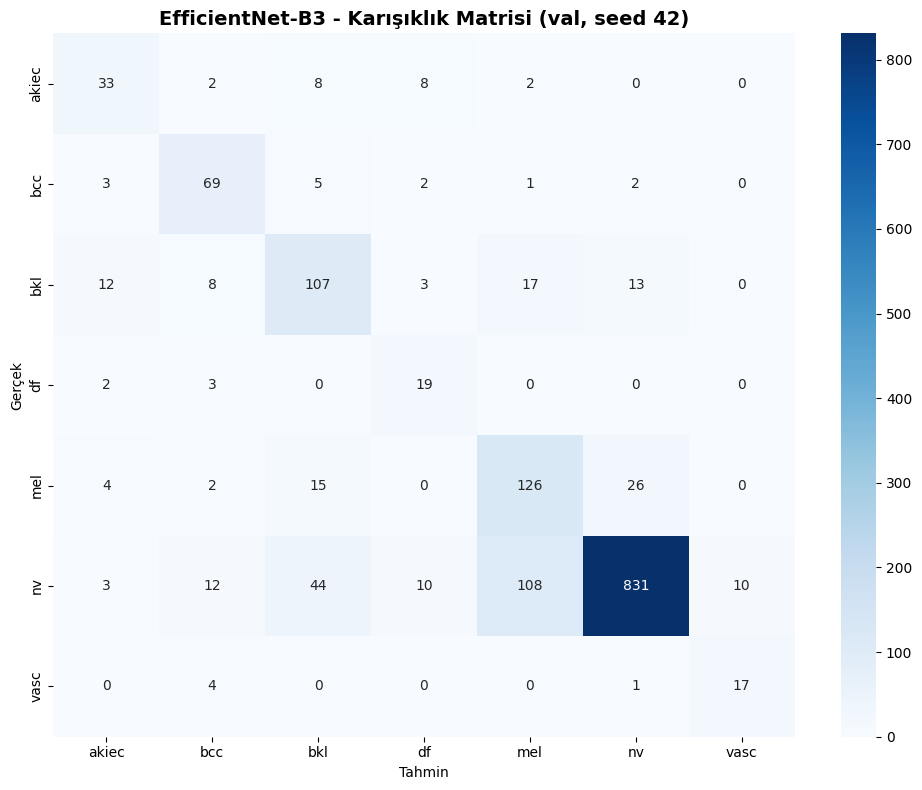

In [5]:
# ============ HÜCRE 5 — EfficientNet-B3 Değerlendirme (val) ============
checkpoint = torch.load(mpath('efficientnet_b3'), map_location=device, weights_only=False)
model = get_model('efficientnet_b3', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_multi['EfficientNet-B3'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'weighted_f1': f1_score(all_labels, all_preds, average='weighted')*100}
print("EfficientNet-B3 (val):", val_results_multi['EfficientNet-B3'])
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'EfficientNet-B3 - Karışıklık Matrisi (val, seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'efficientnet_b3_cm.png', dpi=150); plt.show()

# ResNet50 - Multi-class

In [6]:
# ============ HÜCRE 6 — ResNet50 Eğitim ============
set_seed(SEED)
model = get_model('resnet50', num_classes=7, pretrained=True)
print(f"ResNet50 | Parametreler: {count_parameters(model):,}")

history_resnet_multi = train_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    epochs=30, max_lr=0.0008, save_path=mpath('resnet50'),
    device=device, pct_start=0.3)

ResNet50 | Parametreler: 23,522,375
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\multiclass\resnet50_multiclass_seed42.pth


Epoch   1/30 | Train Loss: 1.9174 Acc: 20.91% | Val Loss: 1.9156 Acc: 24.22% | LR: 0.00006 | Time: 209.7s
   💾 Best model saved! Val Acc: 24.22%


Epoch   2/30 | Train Loss: 1.8611 Acc: 32.46% | Val Loss: 1.7911 Acc: 40.99% | LR: 0.00012 | Time: 209.5s
   💾 Best model saved! Val Acc: 40.99%


Epoch   3/30 | Train Loss: 1.7541 Acc: 41.03% | Val Loss: 1.5916 Acc: 51.24% | LR: 0.00022 | Time: 209.3s
   💾 Best model saved! Val Acc: 51.24%


Epoch   4/30 | Train Loss: 1.5673 Acc: 48.51% | Val Loss: 1.2716 Acc: 57.96% | LR: 0.00035 | Time: 209.5s
   💾 Best model saved! Val Acc: 57.96%


...

Epoch  26/30 | Train Loss: 0.3806 Acc: 85.80% | Val Loss: 0.6927 Acc: 75.26% | LR: 0.00007 | Time: 209.4s


Epoch  27/30 | Train Loss: 0.3445 Acc: 87.60% | Val Loss: 0.6229 Acc: 77.61% | LR: 0.00004 | Time: 209.7s
   💾 Best model saved! Val Acc: 77.61%


Epoch  28/30 | Train Loss: 0.3524 Acc: 87.46% | Val Loss: 0.6901 Acc: 74.87% | LR: 0.00002 | Time: 209.3s


Epoch  29/30 | Train Loss: 0.3394 Acc: 87.94% | Val Loss: 0.6744 Acc: 75.78% | LR: 0.00000 | Time: 209.5s


Epoch  30/30 | Train Loss: 0.3439 Acc: 88.23% | Val Loss: 0.6274 Acc: 77.22% | LR: 0.00000 | Time: 209.2s

EĞİTİM BİTTİ - Toplam süre: 104.8 dakika
En iyi Val Acc: 77.61%
Model kaydedildi: F:\CancerDataClassification\models\multiclass\resnet50_multiclass_seed42.pth


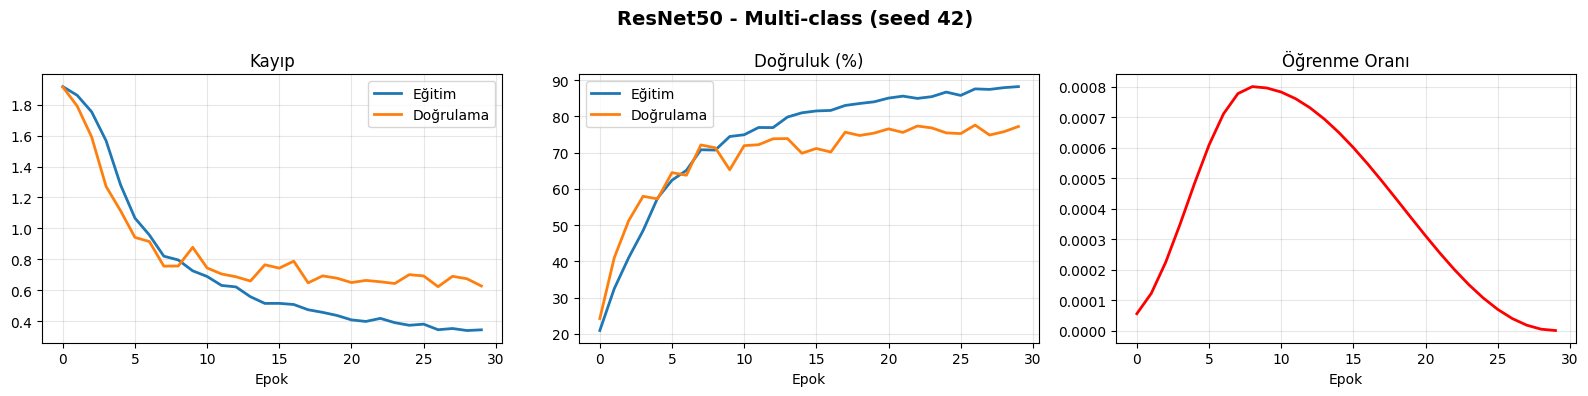

In [7]:
# ============ HÜCRE 7 — ResNet50 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_resnet_multi['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_resnet_multi['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_resnet_multi['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_resnet_multi['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_resnet_multi['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'ResNet50 - Multi-class (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'resnet50_training.png', dpi=150); plt.show()

ResNet50 (val): {'acc': 77.61096605744126, 'macro_f1': 69.2686493971286, 'weighted_f1': 79.1594091449197}
              precision    recall  f1-score   support

       akiec      0.627     0.604     0.615        53
         bcc      0.657     0.866     0.747        82
         bkl      0.551     0.706     0.619       160
          df      0.500     0.750     0.600        24
         mel      0.481     0.792     0.598       173
          nv      0.971     0.786     0.869      1018
        vasc      0.783     0.818     0.800        22

    accuracy                          0.776      1532
   macro avg      0.653     0.760     0.693      1532
weighted avg      0.833     0.776     0.792      1532



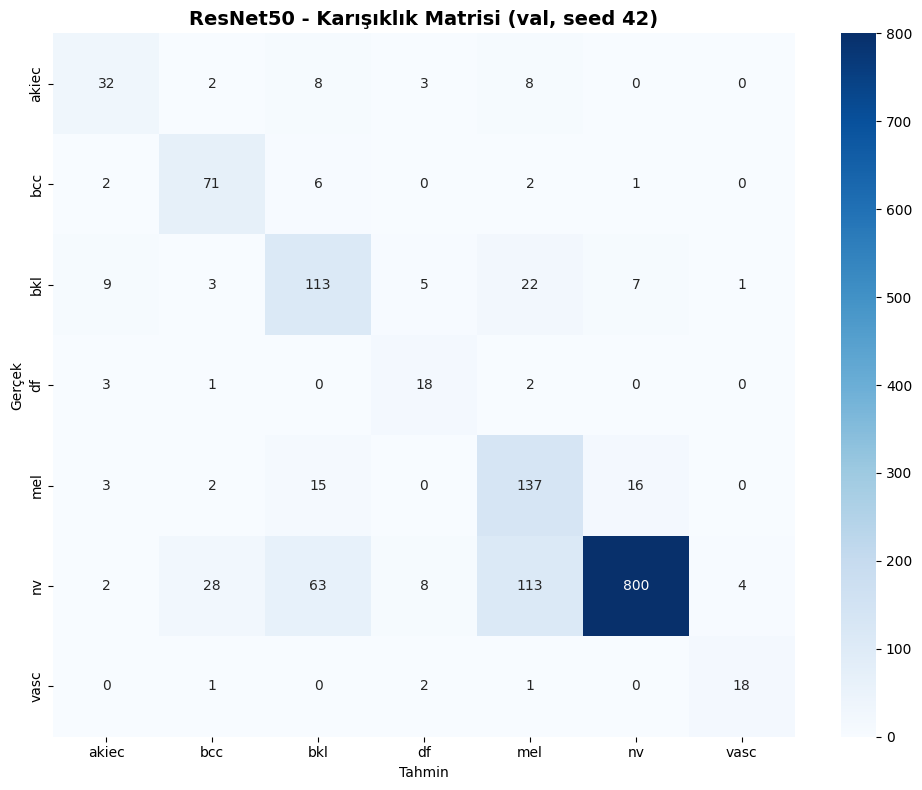

In [8]:
# ============ HÜCRE 8 — ResNet50 Değerlendirme (val) ============
checkpoint = torch.load(mpath('resnet50'), map_location=device, weights_only=False)
model = get_model('resnet50', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_multi['ResNet50'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'weighted_f1': f1_score(all_labels, all_preds, average='weighted')*100}
print("ResNet50 (val):", val_results_multi['ResNet50'])
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'ResNet50 - Karışıklık Matrisi (val, seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'resnet50_cm.png', dpi=150); plt.show()

# DenseNet121

In [9]:
# ============ HÜCRE 9 — DenseNet121 Eğitim ============
set_seed(SEED)
model = get_model('densenet121', num_classes=7, pretrained=True)
print(f"DenseNet121 | Parametreler: {count_parameters(model):,}")

history_densenet_multi = train_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    epochs=30, max_lr=0.0008, save_path=mpath('densenet121'),
    device=device, pct_start=0.3)

DenseNet121 | Parametreler: 6,961,031
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\multiclass\densenet121_multiclass_seed42.pth


Epoch   1/30 | Train Loss: 1.8570 Acc: 26.06% | Val Loss: 1.6586 Acc: 44.32% | LR: 0.00006 | Time: 256.1s
   💾 Best model saved! Val Acc: 44.32%


Epoch   2/30 | Train Loss: 1.5307 Acc: 47.63% | Val Loss: 1.1742 Acc: 58.03% | LR: 0.00012 | Time: 255.3s
   💾 Best model saved! Val Acc: 58.03%


Epoch   3/30 | Train Loss: 1.1176 Acc: 62.69% | Val Loss: 0.9621 Acc: 60.51% | LR: 0.00022 | Time: 255.4s
   💾 Best model saved! Val Acc: 60.51%


Epoch   4/30 | Train Loss: 0.9231 Acc: 66.86% | Val Loss: 0.9343 Acc: 62.34% | LR: 0.00035 | Time: 255.6s
   💾 Best model saved! Val Acc: 62.34%


...

Epoch  26/30 | Train Loss: 0.1767 Acc: 94.34% | Val Loss: 0.6139 Acc: 78.52% | LR: 0.00007 | Time: 313.9s


Epoch  27/30 | Train Loss: 0.1774 Acc: 93.80% | Val Loss: 0.6355 Acc: 78.52% | LR: 0.00004 | Time: 314.0s


Epoch  28/30 | Train Loss: 0.1715 Acc: 94.49% | Val Loss: 0.5972 Acc: 79.50% | LR: 0.00002 | Time: 343.7s


Epoch  29/30 | Train Loss: 0.1680 Acc: 94.03% | Val Loss: 0.6009 Acc: 79.90% | LR: 0.00000 | Time: 320.0s


Epoch  30/30 | Train Loss: 0.1724 Acc: 94.57% | Val Loss: 0.6362 Acc: 78.66% | LR: 0.00000 | Time: 316.9s

EĞİTİM BİTTİ - Toplam süre: 149.3 dakika
En iyi Val Acc: 80.42%
Model kaydedildi: F:\CancerDataClassification\models\multiclass\densenet121_multiclass_seed42.pth


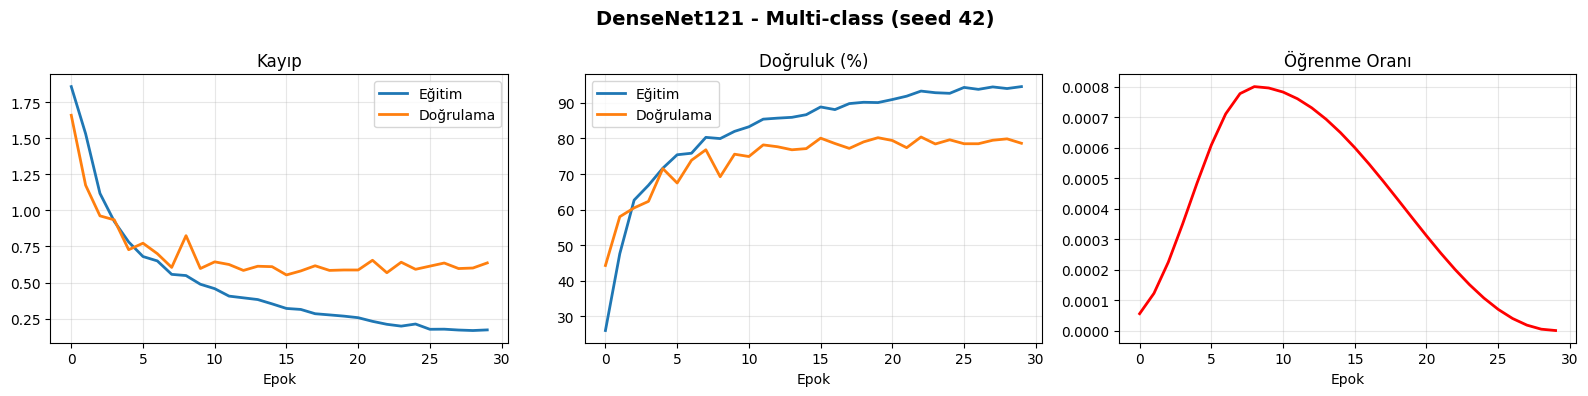

In [10]:
# ============ HÜCRE 10 — DenseNet121 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_densenet_multi['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_densenet_multi['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_densenet_multi['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_densenet_multi['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_densenet_multi['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'DenseNet121 - Multi-class (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'densenet121_training.png', dpi=150); plt.show()

DenseNet121 (val): {'acc': 80.4177545691906, 'macro_f1': 72.49036537635362, 'weighted_f1': 81.24060370384973}
              precision    recall  f1-score   support

       akiec      0.623     0.811     0.705        53
         bcc      0.661     0.878     0.754        82
         bkl      0.598     0.725     0.655       160
          df      0.600     0.750     0.667        24
         mel      0.549     0.653     0.596       173
          nv      0.944     0.838     0.888      1018
        vasc      0.850     0.773     0.810        22

    accuracy                          0.804      1532
   macro avg      0.689     0.775     0.725      1532
weighted avg      0.830     0.804     0.812      1532



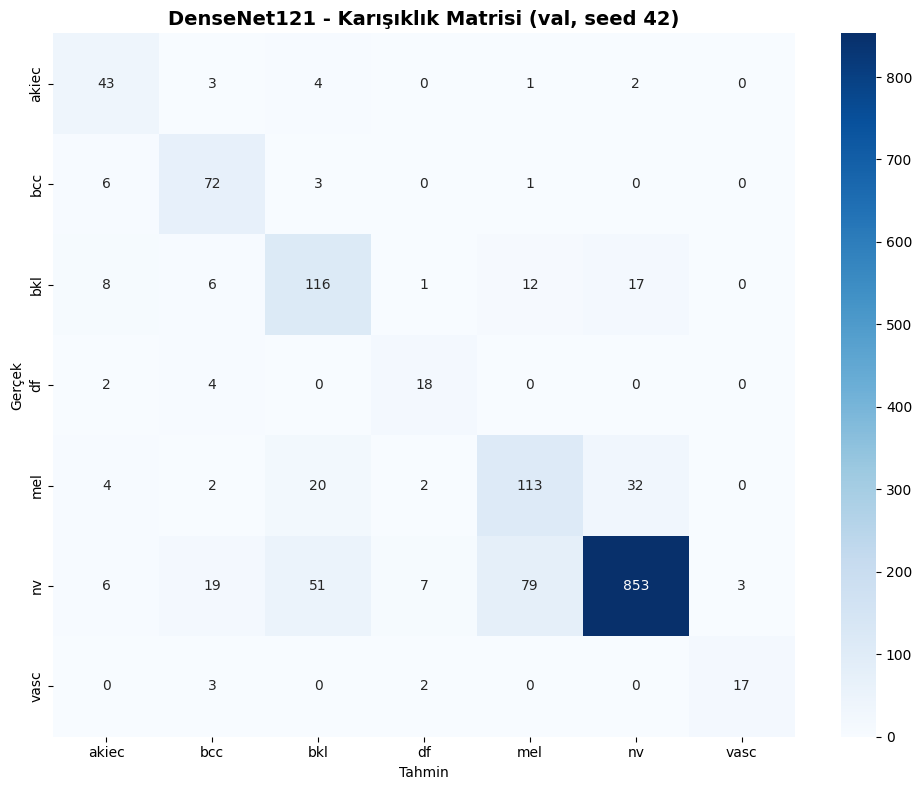

In [11]:
# ============ HÜCRE 11 — DenseNet121 Değerlendirme (val) ============
checkpoint = torch.load(mpath('densenet121'), map_location=device, weights_only=False)
model = get_model('densenet121', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_multi['DenseNet121'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'weighted_f1': f1_score(all_labels, all_preds, average='weighted')*100}
print("DenseNet121 (val):", val_results_multi['DenseNet121'])
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'DenseNet121 - Karışıklık Matrisi (val, seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'densenet121_cm.png', dpi=150); plt.show()

# ConvNeXt-Tiny - Multi-class

In [12]:
# ============ HÜCRE 12 — ConvNeXt-Tiny Eğitim ============
set_seed(SEED)
model = get_model('convnext_tiny', num_classes=7, pretrained=True)
print(f"ConvNeXt-Tiny | Parametreler: {count_parameters(model):,}")

history_convnext_multi = train_model(
    model=model, train_loader=train_loader, val_loader=val_loader,
    epochs=30, max_lr=0.0005, save_path=mpath('convnext_tiny'),
    device=device, pct_start=0.3)

ConvNeXt-Tiny | Parametreler: 27,825,511
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0005
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\multiclass\convnext_tiny_multiclass_seed42.pth


Epoch   1/30 | Train Loss: 1.8805 Acc: 23.89% | Val Loss: 1.6684 Acc: 47.91% | LR: 0.00003 | Time: 306.3s
   💾 Best model saved! Val Acc: 47.91%


Epoch   2/30 | Train Loss: 1.4661 Acc: 47.57% | Val Loss: 1.2132 Acc: 57.05% | LR: 0.00008 | Time: 306.1s
   💾 Best model saved! Val Acc: 57.05%


Epoch   3/30 | Train Loss: 1.1853 Acc: 56.60% | Val Loss: 1.3312 Acc: 48.96% | LR: 0.00014 | Time: 305.3s


Epoch   4/30 | Train Loss: 0.9940 Acc: 63.63% | Val Loss: 1.1975 Acc: 53.00% | LR: 0.00022 | Time: 305.9s


...

Epoch  26/30 | Train Loss: 0.3148 Acc: 88.26% | Val Loss: 0.6238 Acc: 76.96% | LR: 0.00004 | Time: 304.0s


Epoch  27/30 | Train Loss: 0.2859 Acc: 90.03% | Val Loss: 0.5976 Acc: 77.42% | LR: 0.00002 | Time: 304.5s


Epoch  28/30 | Train Loss: 0.2786 Acc: 90.11% | Val Loss: 0.6468 Acc: 74.22% | LR: 0.00001 | Time: 305.0s


Epoch  29/30 | Train Loss: 0.2643 Acc: 90.94% | Val Loss: 0.6562 Acc: 74.80% | LR: 0.00000 | Time: 304.2s


Epoch  30/30 | Train Loss: 0.2517 Acc: 91.20% | Val Loss: 0.6552 Acc: 74.87% | LR: 0.00000 | Time: 304.5s

EĞİTİM BİTTİ - Toplam süre: 152.4 dakika
En iyi Val Acc: 78.79%
Model kaydedildi: F:\CancerDataClassification\models\multiclass\convnext_tiny_multiclass_seed42.pth


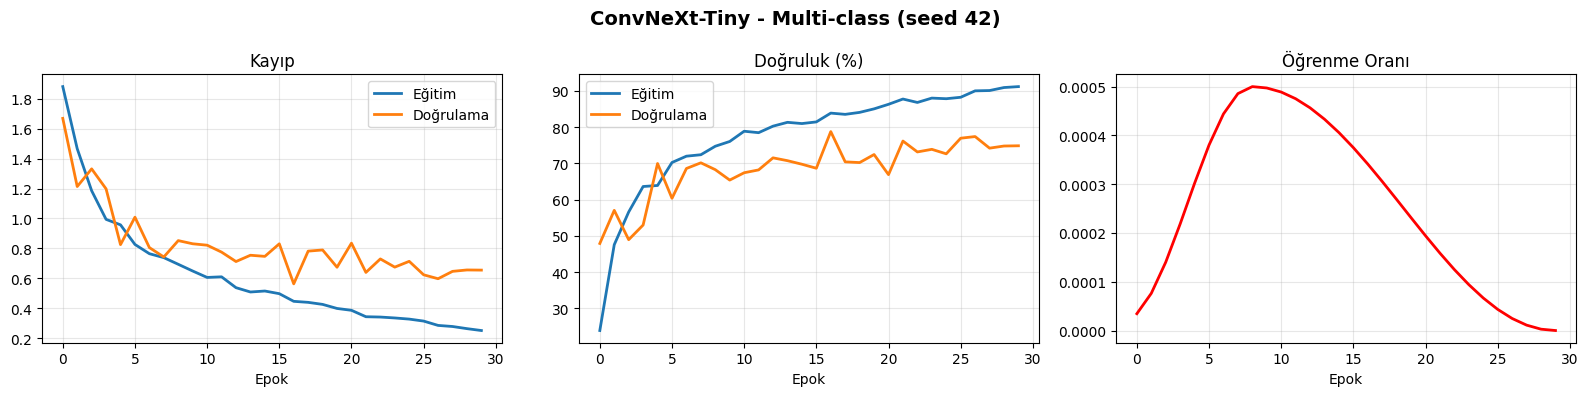

In [13]:
# ============ HÜCRE 13 — ConvNeXt-Tiny Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_convnext_multi['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_convnext_multi['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_convnext_multi['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_convnext_multi['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_convnext_multi['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'ConvNeXt-Tiny - Multi-class (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'convnext_tiny_training.png', dpi=150); plt.show()

ConvNeXt-Tiny (val): {'acc': 78.78590078328982, 'macro_f1': 66.17755121219496, 'weighted_f1': 79.80810687294988}
              precision    recall  f1-score   support

       akiec      0.515     0.321     0.395        53
         bcc      0.660     0.780     0.715        82
         bkl      0.543     0.744     0.628       160
          df      0.500     0.667     0.571        24
         mel      0.522     0.751     0.616       173
          nv      0.958     0.828     0.888      1018
        vasc      0.818     0.818     0.818        22

    accuracy                          0.788      1532
   macro avg      0.645     0.701     0.662      1532
weighted avg      0.825     0.788     0.798      1532



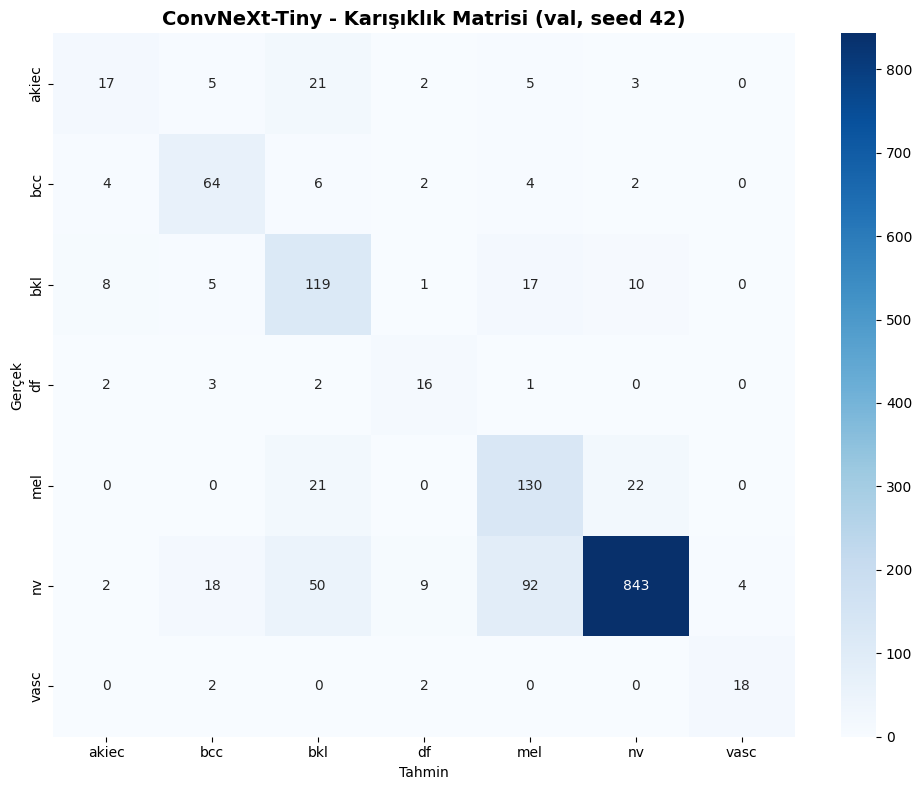

In [14]:
# ============ HÜCRE 14 — ConvNeXt-Tiny Değerlendirme (val) ============
checkpoint = torch.load(mpath('convnext_tiny'), map_location=device, weights_only=False)
model = get_model('convnext_tiny', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_multi['ConvNeXt-Tiny'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'weighted_f1': f1_score(all_labels, all_preds, average='weighted')*100}
print("ConvNeXt-Tiny (val):", val_results_multi['ConvNeXt-Tiny'])
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'ConvNeXt-Tiny - Karışıklık Matrisi (val, seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'convnext_tiny_cm.png', dpi=150); plt.show()

Test seti: 1502 resim (görülmemiş)
DenseNet121        Test Doğruluk %78.50


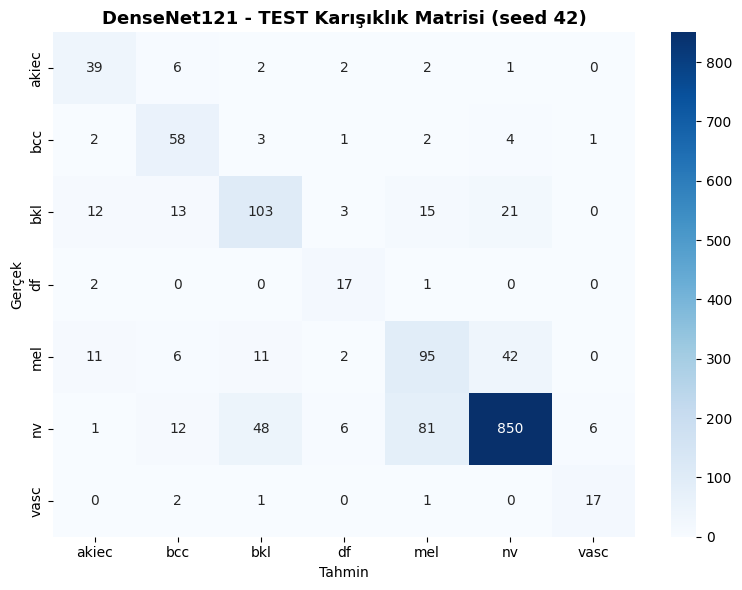

ConvNeXt-Tiny      Test Doğruluk %75.23


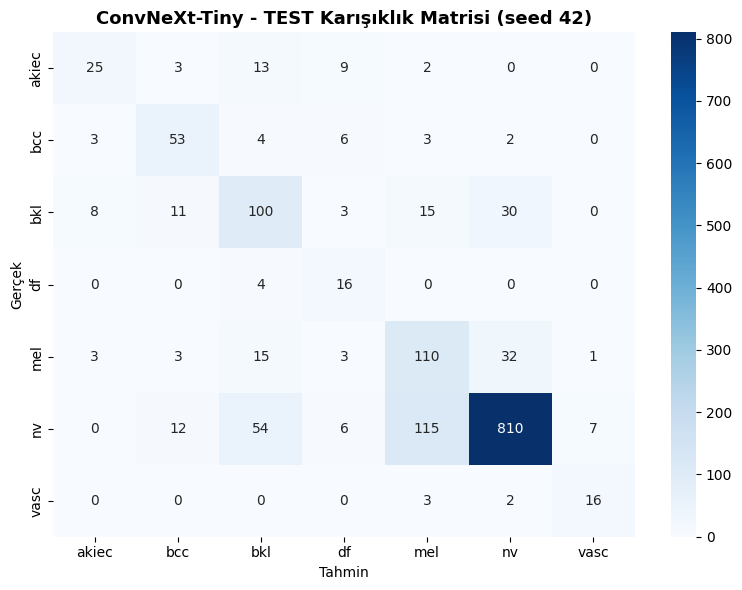

ResNet50           Test Doğruluk %75.90


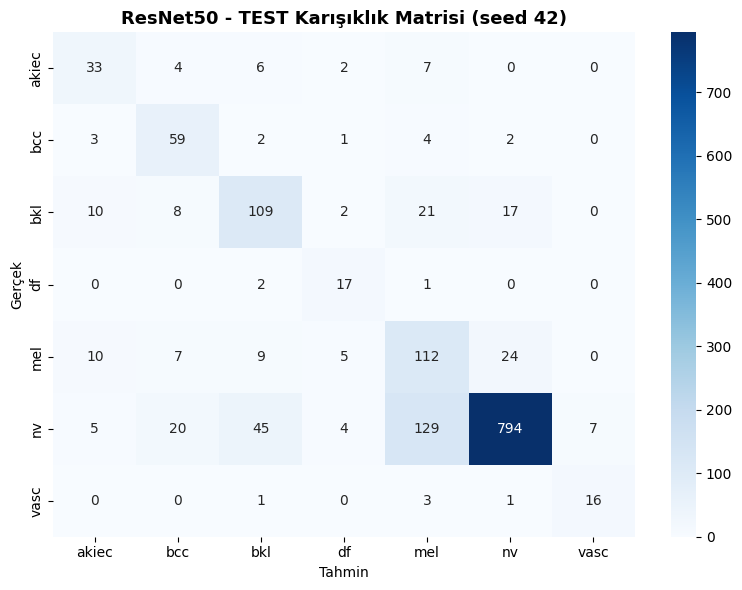

EfficientNet-B3    Test Doğruluk %76.36


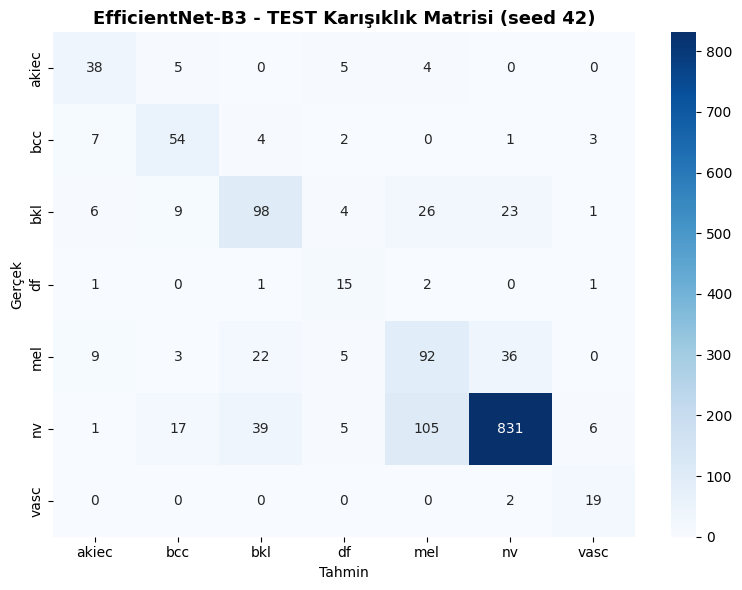


Kaydedildi: F:\CancerDataClassification\results\multiclass\seed42\results.json


In [15]:
# ============ HÜCRE 15 — TEST Seti Değerlendirme (4 model) + TABLOLARI KAYDET ============
test_dataset_multi = HAMDataset(
    csv_path=str(DATA / 'split_test.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='test'))
test_loader_multi = DataLoader(test_dataset_multi, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=True)
print(f"Test seti: {len(test_dataset_multi)} resim (görülmemiş)")

test_models_multi = {
    'DenseNet121':     ('densenet121',     mpath('densenet121')),
    'ConvNeXt-Tiny':   ('convnext_tiny',   mpath('convnext_tiny')),
    'ResNet50':        ('resnet50',        mpath('resnet50')),
    'EfficientNet-B3': ('efficientnet_b3', mpath('efficientnet_b3')),
}

for model_name, (arch, ckpt_path) in test_models_multi.items():
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = get_model(arch, num_classes=7, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device).eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader_multi:
            outputs = model(imgs.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    test_results_multi[model_name] = {
        'acc': accuracy_score(all_labels, all_preds)*100,
        'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
        'weighted_f1': f1_score(all_labels, all_preds, average='weighted')*100}
    print(f"{model_name:<18} Test Doğruluk %{test_results_multi[model_name]['acc']:.2f}")

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} - TEST Karışıklık Matrisi (seed {SEED})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    plt.tight_layout(); plt.savefig(FIG / f'test_{arch}_cm.png', dpi=150); plt.show()

# Bu tohumun TÜM tablolarını tek JSON'a kaydet (val + test)
with open(SEED_DIR / 'results.json', 'w') as f:
    json.dump({'seed': SEED, 'val': val_results_multi, 'test': test_results_multi}, f, indent=2)
print(f"\nKaydedildi: {SEED_DIR / 'results.json'}")

Model             Doğruluk          Makro F1          Ağırlıklı F1      
------------------------------------------------------------------------
DenseNet121       77.39 ± 1.00     69.09 ± 2.24     78.62 ± 0.58     
ConvNeXt-Tiny     75.92 ± 0.87     65.94 ± 2.52     77.29 ± 0.93     
ResNet50          75.97 ± 1.43     66.03 ± 3.46     77.45 ± 1.10     
EfficientNet-B3   76.61 ± 1.18     65.85 ± 0.86     77.95 ± 0.95     

Tablo kaydedildi: F:\CancerDataClassification\results\multiclass\summary\ozet_ort_std.csv


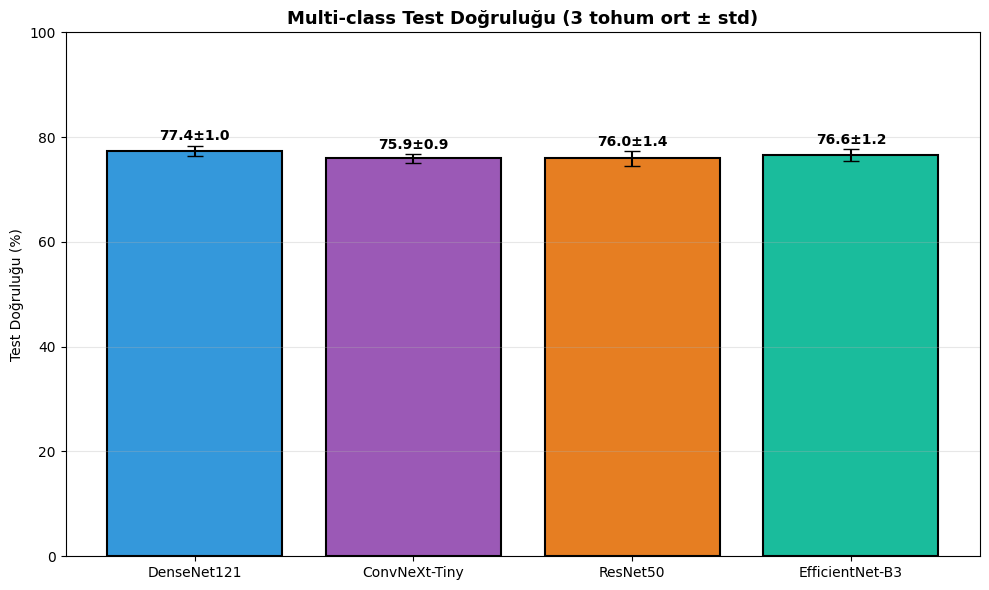

Grafik kaydedildi: F:\CancerDataClassification\results\multiclass\summary\multiclass_test_errorbar.png


In [16]:
# ============ HÜCRE 16 — TÜM TOHUMLARI TOPLA: ort±std tablo + error-bar grafik ============
# (3 tohum da bitince BİR KEZ çalıştır)
seeds  = [13, 21, 42]
models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
metrics = ['acc', 'macro_f1', 'weighted_f1']

SUMMARY = BASE / 'results/multiclass/summary'
SUMMARY.mkdir(parents=True, exist_ok=True)

# topla
agg = {m: {k: [] for k in metrics} for m in models}
for s in seeds:
    r = json.load(open(BASE / f'results/multiclass/seed{s}/results.json'))['test']
    for m in models:
        for k in metrics:
            agg[m][k].append(r[m][k])

# --- tablo yazdır + CSV kaydet ---
import csv
print(f"{'Model':<18}{'Doğruluk':<18}{'Makro F1':<18}{'Ağırlıklı F1':<18}")
print("-"*72)
rows = []
for m in models:
    row = {'model': m}
    line = f"{m:<18}"
    for k in metrics:
        a = np.array(agg[m][k])
        mean, std = a.mean(), a.std(ddof=1)
        row[k+'_mean'] = round(mean, 2); row[k+'_std'] = round(std, 2)
        line += f"{mean:.2f} ± {std:.2f}     "
    print(line); rows.append(row)

with open(SUMMARY / 'ozet_ort_std.csv', 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys()); w.writeheader(); w.writerows(rows)
print(f"\nTablo kaydedildi: {SUMMARY / 'ozet_ort_std.csv'}")

# --- error-bar grafik (doğruluk) ---
means = [np.mean(agg[m]['acc']) for m in models]
stds  = [np.std(agg[m]['acc'], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, means, yerr=stds, capsize=6,
              color=['#3498db', '#9b59b6', '#e67e22', '#1abc9c'], edgecolor='black', linewidth=1.5)
for b, mn, sd in zip(bars, means, stds):
    ax.text(b.get_x()+b.get_width()/2, mn+sd+0.4, f'{mn:.1f}±{sd:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test Doğruluğu (%)'); ax.set_ylim(0, 100)
ax.set_title('Multi-class Test Doğruluğu (3 tohum ort ± std)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(SUMMARY / 'multiclass_test_errorbar.png', dpi=150); plt.show()
print(f"Grafik kaydedildi: {SUMMARY / 'multiclass_test_errorbar.png'}")

In [17]:
# ============ EK HÜCRE A — Multiclass Test Detaylı Per-Sınıf Rapor ============
for model_name, (arch, ckpt_path) in test_models_multi.items():
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = get_model(arch, num_classes=7, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict']); model = model.to(device).eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader_multi:
            all_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
    print("="*70); print(f"TEST: {model_name} (seed {SEED})"); print("="*70)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

TEST: DenseNet121 (seed 42)
              precision    recall  f1-score   support

       akiec      0.582     0.750     0.655        52
         bcc      0.598     0.817     0.690        71
         bkl      0.613     0.617     0.615       167
          df      0.548     0.850     0.667        20
         mel      0.482     0.569     0.522       167
          nv      0.926     0.847     0.884      1004
        vasc      0.708     0.810     0.756        21

    accuracy                          0.785      1502
   macro avg      0.637     0.751     0.684      1502
weighted avg      0.806     0.785     0.792      1502

TEST: ConvNeXt-Tiny (seed 42)
              precision    recall  f1-score   support

       akiec      0.641     0.481     0.549        52
         bcc      0.646     0.746     0.693        71
         bkl      0.526     0.599     0.560       167
          df      0.372     0.800     0.508        20
         mel      0.444     0.659     0.530       167
          nv      0.

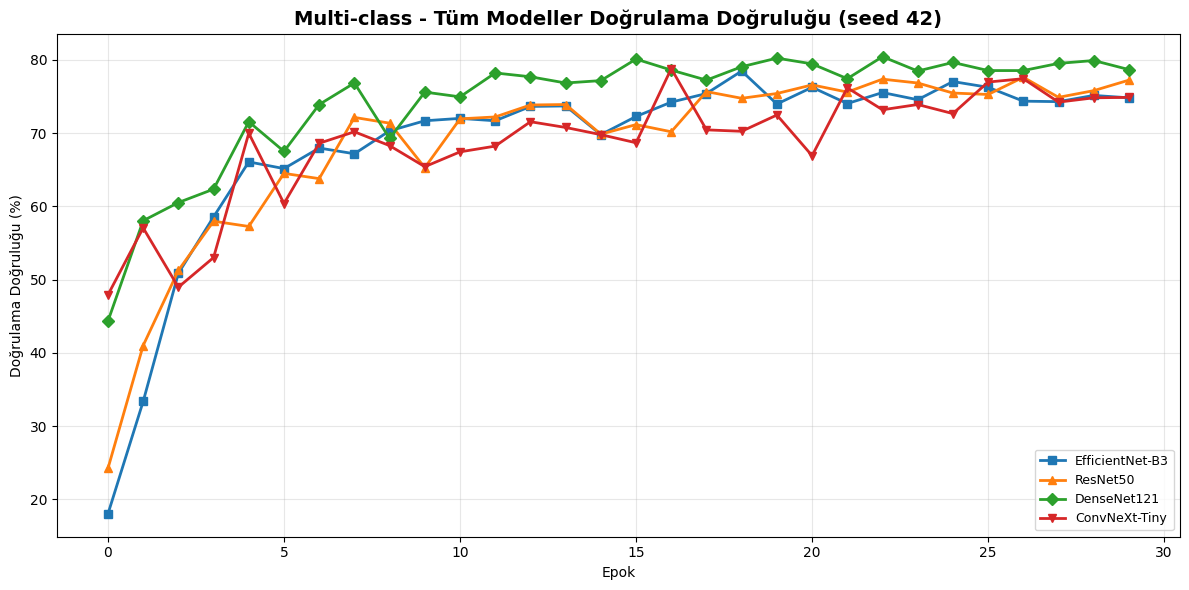

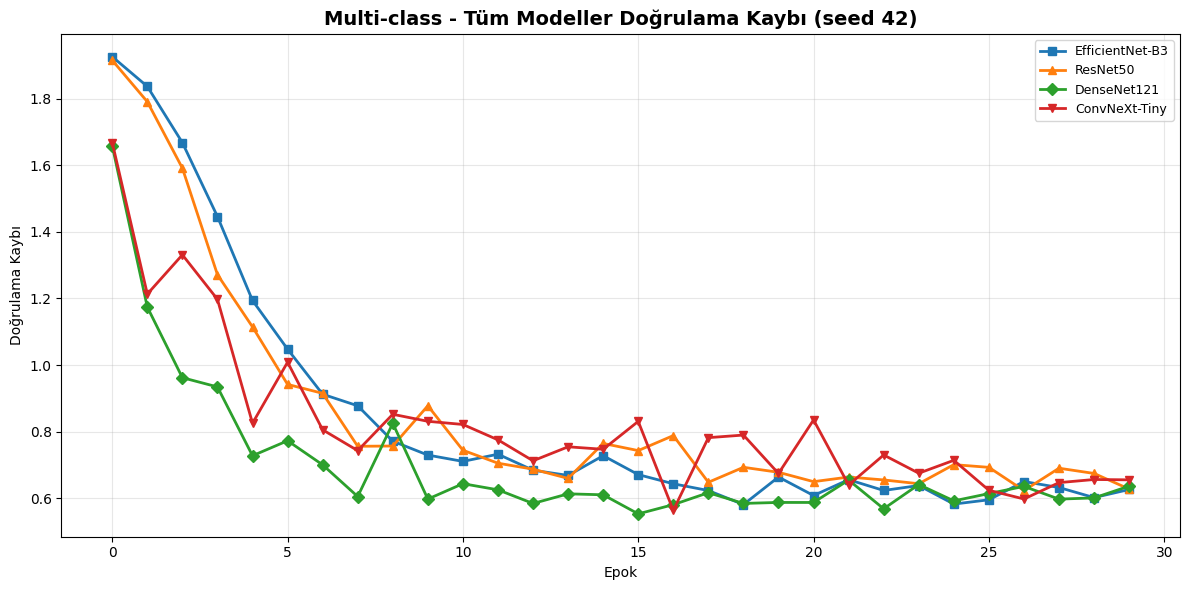

In [18]:
# ============ EK HÜCRE B — Tüm Modeller Val Eğrisi Karşılaştırması ============
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot([a*100 for a in history_b3_multi['val_acc']], label='EfficientNet-B3', linewidth=2, marker='s')
ax.plot([a*100 for a in history_resnet_multi['val_acc']], label='ResNet50', linewidth=2, marker='^')
ax.plot([a*100 for a in history_densenet_multi['val_acc']], label='DenseNet121', linewidth=2, marker='D')
ax.plot([a*100 for a in history_convnext_multi['val_acc']], label='ConvNeXt-Tiny', linewidth=2, marker='v')
ax.set_title(f'Multi-class - Tüm Modeller Doğrulama Doğruluğu (seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Epok'); ax.set_ylabel('Doğrulama Doğruluğu (%)'); ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'tum_modeller_val_dogruluk.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(history_b3_multi['val_loss'], label='EfficientNet-B3', linewidth=2, marker='s')
ax.plot(history_resnet_multi['val_loss'], label='ResNet50', linewidth=2, marker='^')
ax.plot(history_densenet_multi['val_loss'], label='DenseNet121', linewidth=2, marker='D')
ax.plot(history_convnext_multi['val_loss'], label='ConvNeXt-Tiny', linewidth=2, marker='v')
ax.set_title(f'Multi-class - Tüm Modeller Doğrulama Kaybı (seed {SEED})', fontsize=14, fontweight='bold')
ax.set_xlabel('Epok'); ax.set_ylabel('Doğrulama Kaybı'); ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'tum_modeller_val_kayip.png', dpi=150); plt.show()

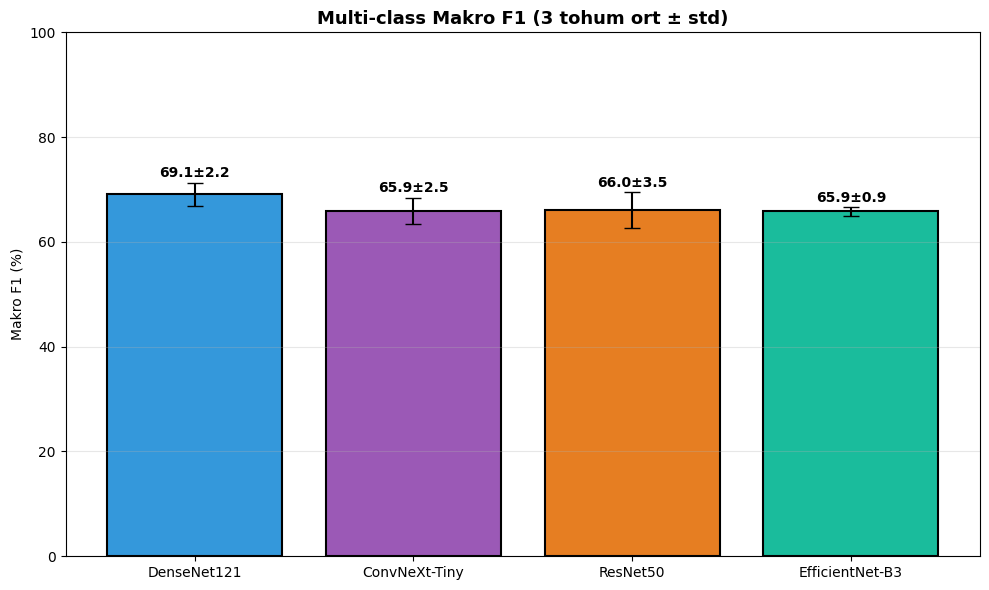

In [19]:
# ============ EK HÜCRE C — Multiclass Makro F1 Özet (3 tohum) ============
import json, numpy as np, matplotlib.pyplot as plt
seeds = [13, 21, 42]; models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
SUMMARY = BASE / 'results/multiclass/summary'; SUMMARY.mkdir(parents=True, exist_ok=True)
f1 = {m: [] for m in models}
for s in seeds:
    r = json.load(open(BASE / f'results/multiclass/seed{s}/results.json'))['test']
    for m in models: f1[m].append(r[m]['macro_f1'])
means = [np.mean(f1[m]) for m in models]; stds = [np.std(f1[m], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, means, yerr=stds, capsize=6, color=['#3498db','#9b59b6','#e67e22','#1abc9c'], edgecolor='black', linewidth=1.5)
for b, mn, sd in zip(bars, means, stds):
    ax.text(b.get_x()+b.get_width()/2, mn+sd+0.4, f'{mn:.1f}±{sd:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Makro F1 (%)'); ax.set_ylim(0, 100)
ax.set_title('Multi-class Makro F1 (3 tohum ort ± std)', fontsize=13, fontweight='bold'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(SUMMARY / 'multiclass_f1_errorbar.png', dpi=150); plt.show()

Model             Lezyon (temiz)      Sizintili           Fark            
--------------------------------------------------------------------------
DenseNet121       77.39 ± 1.00     86.95 ± 0.64     +9.57 ± 0.43
ConvNeXt-Tiny     75.92 ± 0.87     84.48 ± 1.16     +8.56 ± 1.14
ResNet50          75.97 ± 1.43     84.00 ± 1.00     +8.03 ± 1.31
EfficientNet-B3   76.61 ± 1.18     79.38 ± 0.59     +2.77 ± 0.70

Ortalama sızıntı etkisi: +7.23 puan


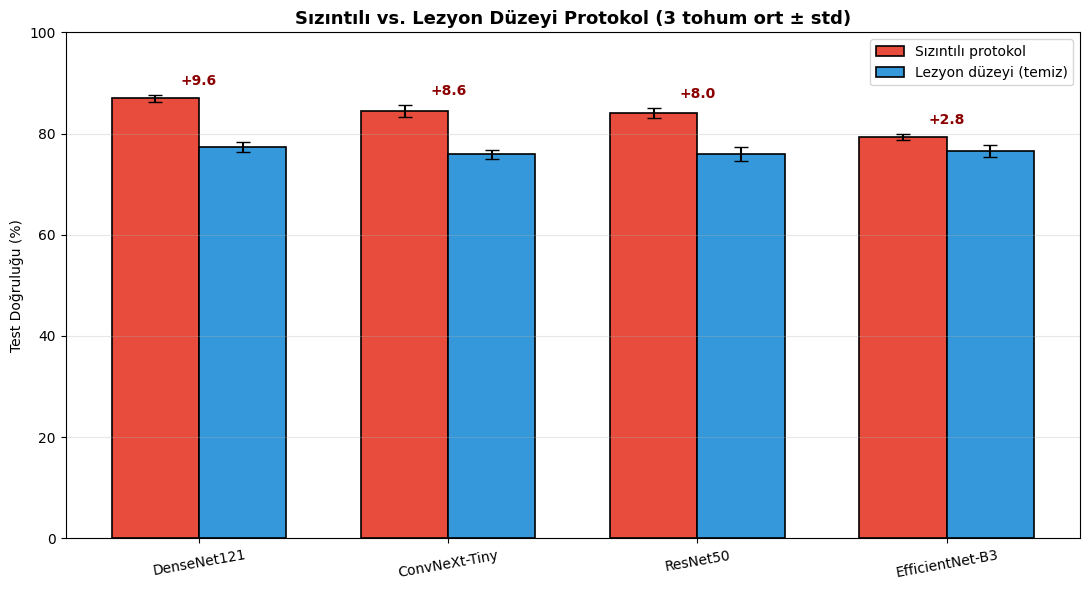

Grafik kaydedildi: F:\CancerDataClassification\results\comparison\sizinti_vs_lezyon_errorbar.png


In [20]:
# ============ EK HÜCRE D — Sızıntılı vs Lezyon Düzeyi (her iki taraf 3 tohum) ============
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
BASE = Path('F:/CancerDataClassification')
seeds = [13, 21, 42]; models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']

clean = {m: [] for m in models}   # lezyon düzeyi (multiclass, temiz)
leaky = {m: [] for m in models}   # sızıntılı
for s in seeds:
    rc = json.load(open(BASE / f'results/multiclass/seed{s}/results.json'))['test']
    rl = json.load(open(BASE / f'results/leak_test_seed{s}.json'))
    for m in models:
        clean[m].append(rc[m]['acc'])
        leaky[m].append(rl[m]['acc'])

# --- tablo ---
print(f"{'Model':<18}{'Lezyon (temiz)':<20}{'Sizintili':<20}{'Fark':<16}")
print("-"*74)
c_m, c_s, l_m, l_s, g_m, g_s = [], [], [], [], [], []
for m in models:
    c = np.array(clean[m]); l = np.array(leaky[m]); g = l - c
    c_m.append(c.mean()); c_s.append(c.std(ddof=1))
    l_m.append(l.mean()); l_s.append(l.std(ddof=1))
    g_m.append(g.mean()); g_s.append(g.std(ddof=1))
    print(f"{m:<18}{c.mean():.2f} ± {c.std(ddof=1):.2f}     {l.mean():.2f} ± {l.std(ddof=1):.2f}     +{g.mean():.2f} ± {g.std(ddof=1):.2f}")
print(f"\nOrtalama sızıntı etkisi: +{np.mean(g_m):.2f} puan")

# --- gruplu error-bar grafik ---
x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x-w/2, l_m, w, yerr=l_s, capsize=5, label='Sızıntılı protokol', color='#e74c3c', edgecolor='black', linewidth=1.2)
ax.bar(x+w/2, c_m, w, yerr=c_s, capsize=5, label='Lezyon düzeyi (temiz)', color='#3498db', edgecolor='black', linewidth=1.2)
for i in range(len(models)):
    top = max(l_m[i]+l_s[i], c_m[i]+c_s[i])
    ax.text(x[i], top+2, f'+{g_m[i]:.1f}', ha='center', fontsize=10, fontweight='bold', color='darkred')
ax.set_ylabel('Test Doğruluğu (%)'); ax.set_ylim(0, 100)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=10)
ax.set_title('Sızıntılı vs. Lezyon Düzeyi Protokol (3 tohum ort ± std)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
COMP = BASE / 'results/comparison'; COMP.mkdir(parents=True, exist_ok=True)
plt.tight_layout(); plt.savefig(COMP / 'sizinti_vs_lezyon_errorbar.png', dpi=150); plt.show()
print(f"Grafik kaydedildi: {COMP / 'sizinti_vs_lezyon_errorbar.png'}")

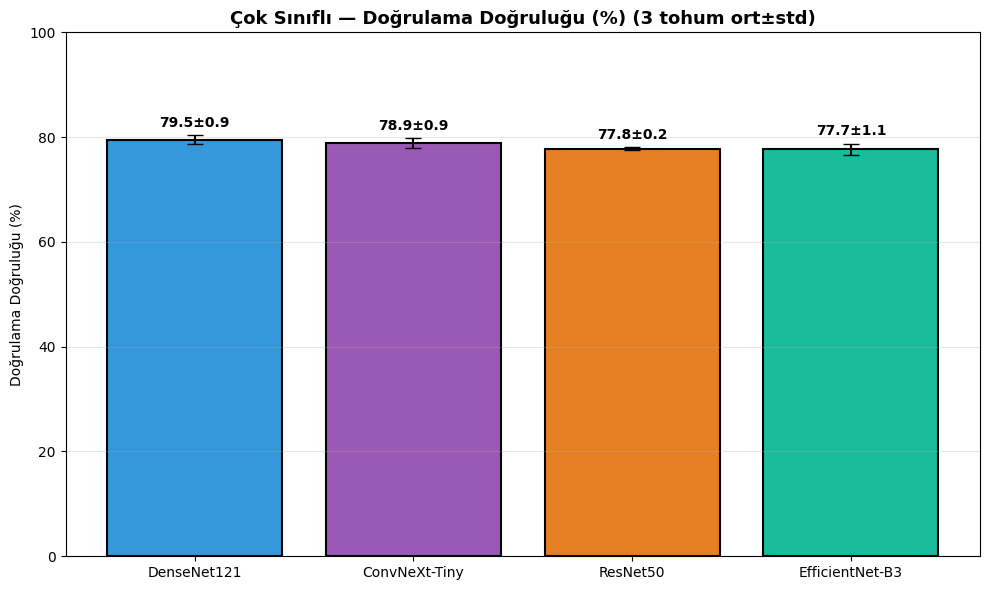

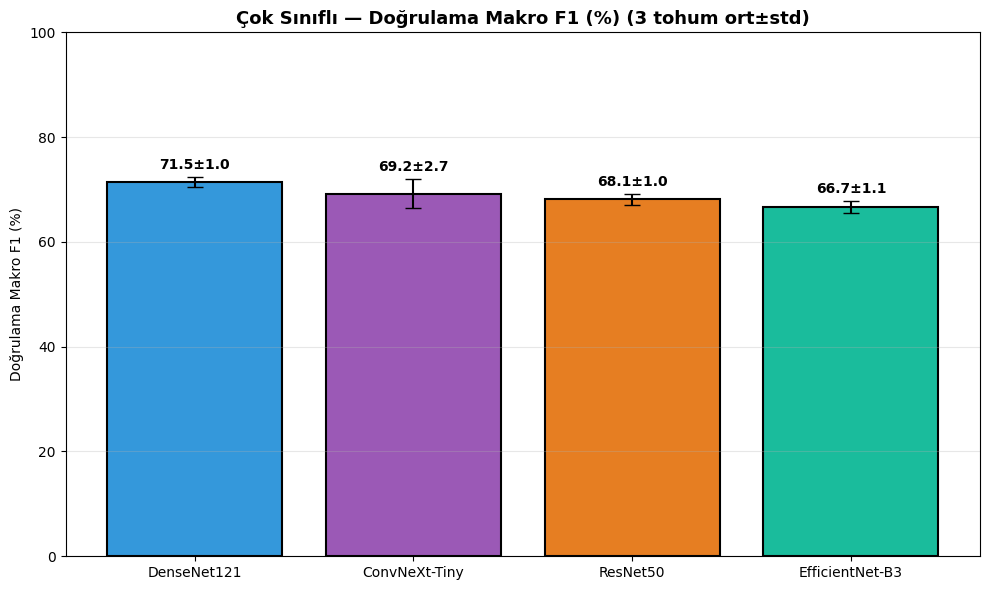

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\CancerDataClassification\\results\\binary\\seed13\\results.json'

In [1]:
# ============ EK HÜCRE E — Eksik Şekiller: val error-bar + sızıntı F1 ============
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
BASE = Path('F:/CancerDataClassification')
seeds = [13, 21, 42]
models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

def errbar(vals, ylabel, title, path, ylim=(0,100), fmt='{:.1f}'):
    m = [np.mean(vals[k]) for k in models]; s = [np.std(vals[k], ddof=1) for k in models]
    fig, ax = plt.subplots(figsize=(10, 6))
    b = ax.bar(models, m, yerr=s, capsize=6, color=colors, edgecolor='black', linewidth=1.5)
    for bar, mm, ss in zip(b, m, s):
        ax.text(bar.get_x()+bar.get_width()/2, mm+ss+ylim[1]*0.01,
                (fmt+'±'+fmt).format(mm, ss), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel); ax.set_ylim(*ylim); ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y'); plt.tight_layout()
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=150); plt.show()

# --- Şekil 9 & 10: çoklu sınıflandırma DOĞRULAMA error-bar ---
for metric, ylab, fn in [('acc','Doğrulama Doğruluğu (%)','sekil09_multi_val_dogruluk.png'),
                         ('macro_f1','Doğrulama Makro F1 (%)','sekil10_multi_val_f1.png')]:
    v = {m: [json.load(open(BASE/f'results/multiclass/seed{s}/results.json'))['val'][m][metric] for s in seeds] for m in models}
    errbar(v, ylab, f'Çok Sınıflı — {ylab} (3 tohum ort±std)', BASE/f'results/multiclass/summary/{fn}')

# --- Şekil 21 & 22: ikili DOĞRULAMA error-bar ---
v = {m: [json.load(open(BASE/f'results/binary/seed{s}/results.json'))['val'][m]['acc'] for s in seeds] for m in models}
errbar(v, 'Doğrulama Doğruluğu (%)', 'İkili — Doğruluk (3 tohum ort±std)', BASE/'results/binary/summary/sekil21_binary_val_dogruluk.png')
v = {m: [json.load(open(BASE/f'results/binary/seed{s}/results.json'))['val'][m]['auc'] for s in seeds] for m in models}
errbar(v, 'Doğrulama AUC-ROC', 'İkili — AUC-ROC (3 tohum ort±std)', BASE/'results/binary/summary/sekil22_binary_val_auc.png', ylim=(0,1.0), fmt='{:.3f}')

# --- Şekil 34: sızıntı vs doğru, MAKRO F1 ---
clean = {m: [json.load(open(BASE/f'results/multiclass/seed{s}/results.json'))['test'][m]['macro_f1'] for s in seeds] for m in models}
leaky = {m: [json.load(open(BASE/f'results/leak_test_seed{s}.json'))[m]['macro_f1'] for s in seeds] for m in models}
x = np.arange(len(models)); w = 0.35
cm_, cs_ = [np.mean(clean[m]) for m in models], [np.std(clean[m], ddof=1) for m in models]
lm_, ls_ = [np.mean(leaky[m]) for m in models], [np.std(leaky[m], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x-w/2, lm_, w, yerr=ls_, capsize=5, label='Sızıntılı', color='#e74c3c', edgecolor='black')
ax.bar(x+w/2, cm_, w, yerr=cs_, capsize=5, label='Lezyon düzeyi', color='#3498db', edgecolor='black')
for i in range(len(models)):
    ax.text(x[i], max(lm_[i]+ls_[i], cm_[i]+cs_[i])+2, f'+{lm_[i]-cm_[i]:.1f}',
            ha='center', fontsize=10, fontweight='bold', color='darkred')
ax.set_ylabel('Makro F1 (%)'); ax.set_ylim(0, 100); ax.set_xticks(x); ax.set_xticklabels(models, rotation=10)
ax.set_title('Sızıntı Etkisi — Makro F1 (3 tohum ort±std)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()
plt.savefig(BASE/'results/comparison/sekil34_sizinti_f1_errorbar.png', dpi=150); plt.show()